In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.spatial import KDTree
%matplotlib inline

In [11]:
# Load Dipole Data

data = loadmat('emptyEEG.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'EEG', 'lf'])

In [12]:
# Initialize Parameters

lf = data['lf']
gain = lf['Gain'][0, 0]
locations = lf['GridLoc'][0, 0]
dipole_of_interest = 109

sampling_rate = 1004
time_vector = np.arange(-1, 1, 1/sampling_rate)
timepoints = len(time_vector)

gain.shape, locations.shape, timepoints

((64, 3, 2004), (2004, 3), 2008)

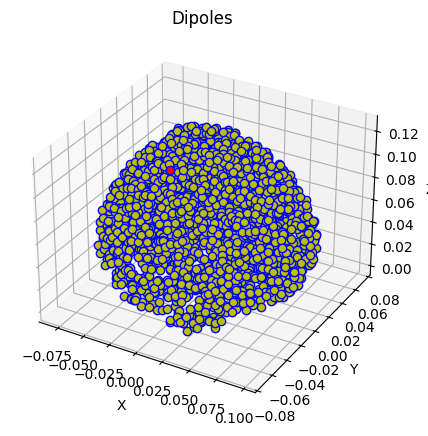

In [13]:
# Plot Dipoles in a 3D

plt.close('all')
fig = plt.figure(figsize=(7, 5))
ax = plt.axes(projection='3d')
ax.plot3D(locations[:, 0], locations[:, 1], locations[:, 2], 'bo', markerfacecolor='y')
ax.plot3D(locations[dipole_of_interest, 0], locations[dipole_of_interest, 1], locations[dipole_of_interest, 2], 'bo', markerfacecolor='r')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Dipoles')
plt.show()

In [14]:
# Initialize Dipole Activity Variable

dipole_act = np.zeros((gain.shape[2], timepoints))

# Simulate Dipole 'Activity'

dipole_act[dipole_of_interest, :] = np.sin(2 * np.pi * 10 * time_vector)

# Project Dipole Activity onto Channels

eeg_data = np.matmul(gain[:, 0, :], dipole_act)
eeg_data.shape

(64, 2008)